In [66]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, auc
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier


In [2]:
df_test_f = pd.read_csv('test_final_processed.csv')
df_test_f

,sk_id_curr,name_contract_type,code_gender,flag_own_car,flag_own_realty,cnt_children,amt_income_total,amt_credit,amt_annuity,amt_goods_price,...,ip_version_56.0_mean,ip_version_57.0_mean,ip_version_58.0_mean,ip_version_59.0_mean,ip_version_61.0_mean,ip_version_68.0_mean,ip_version_72.0_mean,ip_version_73.0_mean,ip_version_178.0_mean,ip_version_nan_mean
0,100001,Cash loans,F,N,Y,0,135000.0,568800.0,20560.5,450000.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,100005,Cash loans,M,N,Y,0,99000.0,222768.0,17370.0,180000.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,100013,Cash loans,M,Y,Y,0,202500.0,663264.0,69777.0,630000.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,100028,Cash loans,F,N,Y,2,315000.0,1575000.0,49018.5,1575000.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,100038,Cash loans,M,Y,N,1,180000.0,625500.0,32067.0,625500.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48739,456221,Cash loans,F,N,Y,0,121500.0,412560.0,17473.5,270000.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
48740,456222,Cash loans,F,N,N,2,157500.0,622413.0,31909.5,495000.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
48741,456223,Cash loans,F,Y,Y,1,202500.0,315000.0,33205.5,315000.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
48742,456224,Cash loans,M,N,N,0,225000.0,450000.0,25128.0,450000.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
df_train_f = pd.read_csv('train_final_processed.csv')
df_train_f

,sk_id_curr,target,name_contract_type,code_gender,flag_own_car,flag_own_realty,cnt_children,amt_income_total,amt_credit,amt_annuity,...,ip_version_56.0_mean,ip_version_57.0_mean,ip_version_58.0_mean,ip_version_59.0_mean,ip_version_61.0_mean,ip_version_68.0_mean,ip_version_72.0_mean,ip_version_73.0_mean,ip_version_178.0_mean,ip_version_nan_mean
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,456251,0,Cash loans,M,N,N,0,157500.0,254700.0,27558.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
307507,456252,0,Cash loans,F,N,Y,0,72000.0,269550.0,12001.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
307508,456253,0,Cash loans,F,N,Y,0,153000.0,677664.0,29979.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
307509,456254,1,Cash loans,F,N,Y,0,171000.0,370107.0,20205.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
print(df_train_f.isnull().sum().sum())
print(df_test_f.isnull().sum().sum())


0
0


In [14]:
df_train_f['target'].value_counts()

target
0    282686
1     24825
Name: count, dtype: int64

In [27]:
print("Доля target=1 в df_train_f:", df_train_f['target'].mean())

Доля target=1 в df_train_f: 0.08072881945686496


Создание BaseModel

In [17]:
X = df_train_f.drop(columns=['sk_id_curr', 'target'])
y = df_train_f['target']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [30]:
categorical_columns = X_train.select_dtypes(include=['object']).columns
print(f"Категориальные колонки: {list(categorical_columns)}")

X_train_encoded = pd.get_dummies(X_train, columns=categorical_columns, prefix=categorical_columns, drop_first=True)

Категориальные колонки: ['name_contract_type', 'code_gender', 'flag_own_car', 'flag_own_realty', 'name_type_suite', 'name_income_type', 'name_education_type', 'name_family_status', 'name_housing_type', 'occupation_type', 'weekday_appr_process_start', 'organization_type', 'fondkapremont_mode', 'housetype_mode', 'wallsmaterial_mode', 'emergencystate_mode']


In [34]:
X_val_encoded = pd.get_dummies(X_val, columns=categorical_columns, prefix=categorical_columns, drop_first=True)

for col in X_train_encoded.columns:
    if col not in X_val_encoded.columns:
        X_val_encoded[col] = 0

X_val_encoded = X_val_encoded[X_train_encoded.columns]

Gradient Boosting

In [50]:
base_model = GradientBoostingClassifier(random_state=42)
base_model.fit(X_train_encoded, y_train)

GradientBoostingClassifier(random_state=42)

In [51]:
y_val_pred_proba = base_model.predict_proba(X_val_encoded)[:, 1]
y_val_pred = (y_val_pred_proba >= 0.5).astype(int)

In [52]:
accuracy = accuracy_score(y_val, y_val_pred)
precision = precision_score(y_val, y_val_pred) 
recall = recall_score(y_val, y_val_pred)
f1 = f1_score(y_val, y_val_pred)
roc_auc = roc_auc_score(y_val, y_val_pred_proba)

print(f"ROC-AUC: {roc_auc:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

ROC-AUC: 0.7684
Accuracy: 0.9201
Precision: 0.5855
Recall: 0.0228
F1-Score: 0.0440


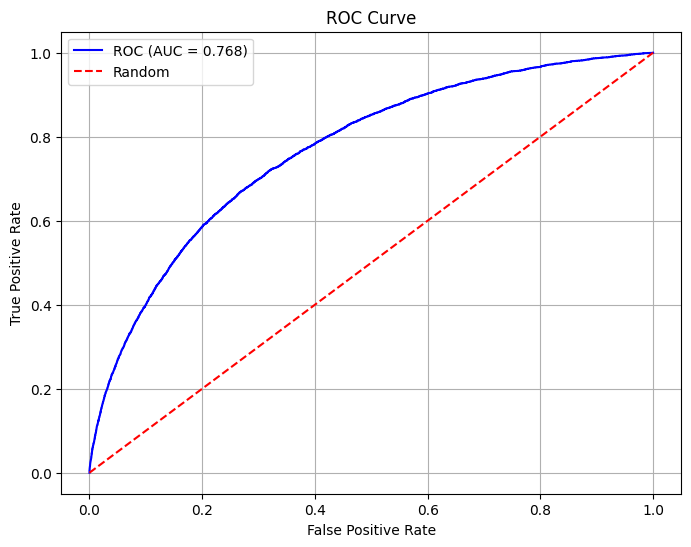

In [ ]:
fpr, tpr, _ = roc_curve(y_val, y_val_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, 'b-', label=f'ROC (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'r--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate') 
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

Random Forest

In [67]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_encoded, y_train)

RandomForestClassifier(random_state=42)

In [68]:
y_pred_rf_proba = rf_model.predict_proba(X_val_encoded)[:, 1]
y_pred_rf = (y_pred_rf_proba >= 0.5).astype(int)

In [69]:
rf_auc = roc_auc_score(y_val, y_pred_rf_proba)
rf_accuracy = accuracy_score(y_val, y_pred_rf)
rf_precision = precision_score(y_val, y_pred_rf)
rf_recall = recall_score(y_val, y_pred_rf)
rf_f1 = f1_score(y_val, y_pred_rf)

print(f"ROC-AUC: {rf_auc:.4f}")
print(f"Accuracy: {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall: {rf_recall:.4f}")
print(f"F1-Score: {rf_f1:.4f}")

ROC-AUC: 0.7159
Accuracy: 0.9195
Precision: 0.5263
Recall: 0.0020
F1-Score: 0.0040


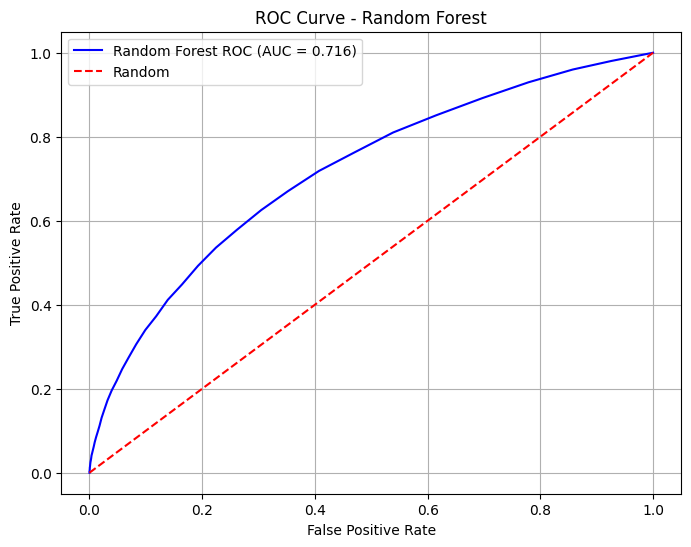

In [70]:
fpr_rf, tpr_rf, _ = roc_curve(y_val, y_pred_rf_proba)
roc_auc_xgb = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, 'b-', label=f'Random Forest ROC (AUC = {roc_auc_xgb:.3f})')
plt.plot([0, 1], [0, 1], 'r--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate') 
plt.title('ROC Curve - Random Forest')
plt.legend()
plt.grid(True)
plt.show()

алгоритм XGBoost

In [53]:
xgb_model = XGBClassifier(random_state=42)
xgb_model.fit(X_train_encoded, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [54]:
y_pred_xgb_proba = xgb_model.predict_proba(X_val_encoded)[:, 1]
y_pred_xgb = (y_pred_xgb_proba >= 0.5).astype(int)

In [55]:
xgb_auc = roc_auc_score(y_val, y_pred_xgb_proba)
xgb_accuracy = accuracy_score(y_val, y_pred_xgb)
xgb_precision = precision_score(y_val, y_pred_xgb)
xgb_recall = recall_score(y_val, y_pred_xgb)
xgb_f1 = f1_score(y_val, y_pred_xgb)

print(f"ROC-AUC: {xgb_auc:.4f}")
print(f"Accuracy: {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall: {xgb_recall:.4f}")
print(f"F1-Score: {xgb_f1:.4f}")

ROC-AUC: 0.7689
Accuracy: 0.9193
Precision: 0.4898
Recall: 0.0725
F1-Score: 0.1264


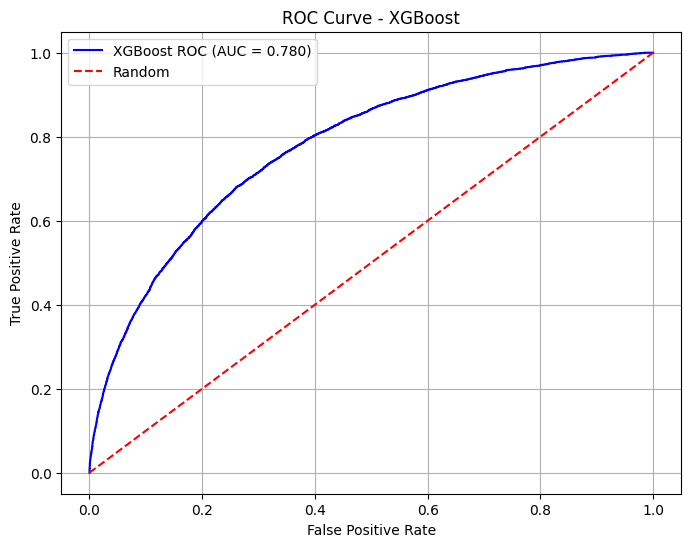

In [47]:
fpr_xgb, tpr_xgb, _ = roc_curve(y_val, y_pred_xgb_proba)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)

plt.figure(figsize=(8, 6))
plt.plot(fpr_xgb, tpr_xgb, 'b-', label=f'XGBoost ROC (AUC = {roc_auc_xgb:.3f})')
plt.plot([0, 1], [0, 1], 'r--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate') 
plt.title('ROC Curve - XGBoost')
plt.legend()
plt.grid(True)
plt.show()

In [60]:

cat_model = CatBoostClassifier()
cat_model.fit(X_train_encoded, y_train)

Learning rate set to 0.108111
0:	learn: 0.5866691	total: 2.78s	remaining: 46m 19s
1:	learn: 0.5072030	total: 3.14s	remaining: 26m 5s
2:	learn: 0.4480809	total: 3.39s	remaining: 18m 45s
3:	learn: 0.4023785	total: 3.64s	remaining: 15m 7s
4:	learn: 0.3676625	total: 3.93s	remaining: 13m 2s
5:	learn: 0.3434901	total: 4.2s	remaining: 11m 35s
6:	learn: 0.3241027	total: 4.57s	remaining: 10m 47s
7:	learn: 0.3094113	total: 4.93s	remaining: 10m 11s
8:	learn: 0.2974993	total: 5.79s	remaining: 10m 38s
9:	learn: 0.2886401	total: 6.34s	remaining: 10m 27s
10:	learn: 0.2821761	total: 6.76s	remaining: 10m 8s
11:	learn: 0.2766288	total: 7.12s	remaining: 9m 45s
12:	learn: 0.2718529	total: 7.55s	remaining: 9m 33s
13:	learn: 0.2679728	total: 8.07s	remaining: 9m 28s
14:	learn: 0.2654290	total: 8.58s	remaining: 9m 23s
15:	learn: 0.2628417	total: 8.93s	remaining: 9m 9s
16:	learn: 0.2609504	total: 9.25s	remaining: 8m 54s
17:	learn: 0.2593939	total: 9.76s	remaining: 8m 52s
18:	learn: 0.2577372	total: 10.2s	remai

In [61]:
y_pred_cat_proba = cat_model.predict_proba(X_val_encoded)[:, 1]
y_pred_cat = (y_pred_cat_proba >= 0.5).astype(int)


In [63]:
cat_auc = roc_auc_score(y_val, y_pred_cat_proba)
cat_accuracy = accuracy_score(y_val, y_pred_cat)
cat_precision = precision_score(y_val, y_pred_cat)
cat_recall = recall_score(y_val, y_pred_cat)
cat_f1 = f1_score(y_val, y_pred_cat)

print(f"ROC-AUC: {cat_auc:.4f}")
print(f"Accuracy: {cat_accuracy:.4f}")
print(f"Precision: {cat_precision:.4f}")
print(f"Recall: {cat_recall:.4f}")
print(f"F1-Score: {cat_f1:.4f}")

ROC-AUC: 0.7846
Accuracy: 0.9206
Precision: 0.5714
Recall: 0.0550
F1-Score: 0.1003


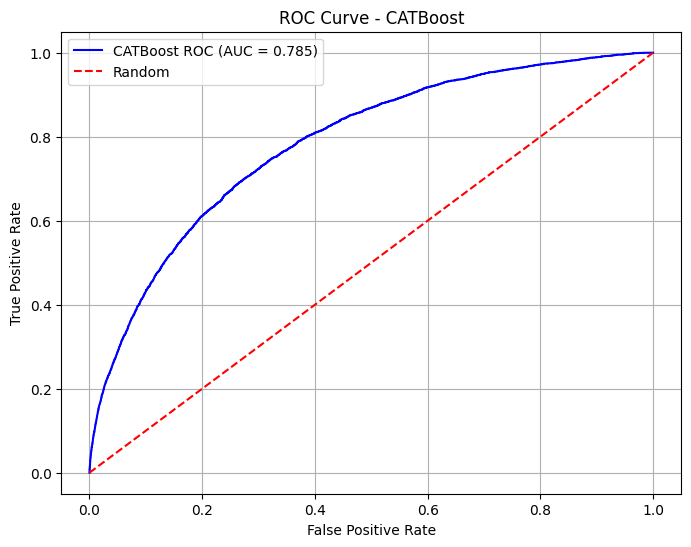

In [64]:
fpr_cat, tpr_cat, _ = roc_curve(y_val, y_pred_cat_proba)
roc_auc_cat = auc(fpr_cat, tpr_cat)

plt.figure(figsize=(8, 6))
plt.plot(fpr_cat, tpr_cat, 'b-', label=f'CATBoost ROC (AUC = {roc_auc_cat:.3f})')
plt.plot([0, 1], [0, 1], 'r--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate') 
plt.title('ROC Curve - CATBoost')
plt.legend()
plt.grid(True)
plt.show()